# Opciones sobre META

### Análisis de opciones y simulación
## Abraham Flores
## Andre Esteban

En este notebook se analiza el comportamiento del precio de **Meta Platforms (META)** y se calculan los payoffs de distintos tipos de opciones utilizando precios históricos.

---


## 1. Datos históricos de META

Primero se descargan los precios históricos de **META** y se toma la serie de precios de cierre para realizar el análisis.


In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
ticker="META"

df = yf.download(ticker, period='6mo')
df
prices = df['Close']
#si quiero que no cuente el dato de hoy 
prices = prices[:-1]
prices.tail()

[*********************100%***********************]  1 of 1 completed


Ticker,META
Date,
2026-09-16,672.779053
2026-09-17,681.771973
2026-09-18,665.225037
2026-09-21,741.250000
2026-09-22,736.599976


### Evolución del precio

A continuación se muestra gráficamente el comportamiento del precio de cierre de META durante el periodo analizado.


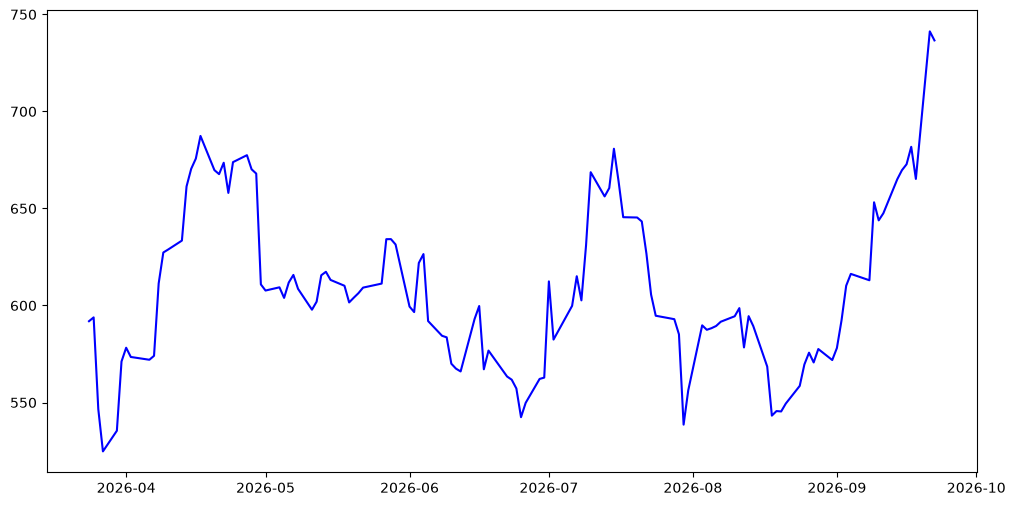

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(prices.index, prices.values, label='META Closing Prices', color='blue')
plt.show()

---

## 2. Opción Europea

Para una opción europea, el payoff se determina únicamente con el precio del activo al vencimiento.

Sea:

- $S_0$: precio inicial del activo.
- $S_T$: precio del activo al vencimiento.
- $K$: precio de ejercicio.

En este ejercicio se utiliza:

$$
K = S_0
$$

Los payoffs son:

$$
\text{Call Europea} = \max(S_T-K,0)
$$

$$
\text{Put Europea} = \max(K-S_T,0)
$$


In [4]:
S0 = df["Close"].iloc[0].item()
ST = df["Close"].iloc[-1].item()
K = S0

S0, ST, K

(591.9038696289062, 744.0999755859375, 591.9038696289062)

In [5]:
payoff_call_EU = max(ST - K, 0)

payoff_put_EU = max(K - ST, 0)

payoff_call_EU, payoff_put_EU

(152.19610595703125, 0)

---

## 3. Opción Asiática

La opción asiática depende del **precio promedio del activo** durante el periodo analizado.

Primero se calcula:

$$
\bar{S} = \frac{1}{n}\sum_{t=1}^{n} S_t
$$

Después, los payoffs son:

$$
\text{Call Asiática} = \max(\bar{S}-K,0)
$$

$$
\text{Put Asiática} = \max(K-\bar{S},0)
$$


In [6]:
promedio = df["Close"].mean().item()

promedio

609.6598645307886

In [7]:
payoff_call_AS = max(promedio - K, 0)

payoff_put_AS = max(K - promedio, 0)

payoff_call_AS, payoff_put_AS

(17.75599490188233, 0)

---

## 4. Opción Lookback con Strike Flotante

Una opción Lookback utiliza el precio máximo o mínimo alcanzado por el activo durante el periodo.

Se definen:

$$
S_{\max} = \max(S_t)
$$

$$
S_{\min} = \min(S_t)
$$

Para una opción Lookback con strike flotante:

$$
\text{Call Lookback} = S_T-S_{\min}
$$

$$
\text{Put Lookback} = S_{\max}-S_T
$$


In [8]:
maximo = df["Close"].max().item()
minimo = df["Close"].min().item()

payoff_call_LB = ST - minimo
payoff_put_LB = maximo - ST

payoff_call_LB, payoff_put_LB

(219.28094482421875, 0.0)

---

## 5. Simulación Monte Carlo

Finalmente se realiza una simulación del precio de META utilizando los rendimientos históricos.

Los datos se dividen en dos periodos:

- **Train:** periodo utilizado para estimar el rendimiento promedio y la volatilidad.
- **Test:** periodo utilizado para comparar la trayectoria simulada con el comportamiento real.

Se generan **10,000 escenarios** de precios y posteriormente se comparan algunas trayectorias simuladas contra el precio real de META.


In [9]:
df = yf.download(ticker,start="2025-09-23",end="2026-09-24")

Prices = df["Close"]

rets = np.log(Prices / Prices.shift(1))
rets = rets.dropna()

Train = rets[(rets.index >= "2025-09-23") &(rets.index <= "2026-03-23")]

Test = rets[(rets.index > "2026-03-23") &(rets.index <= "2026-09-23")]

Mu = Train.mean()
Sigma = Train.std()
S0 = Prices.loc[:"2026-03-23"].iloc[-1]

M = 10000
n = 126

mu = Mu["META"]
sigma = Sigma["META"]
s0 = S0["META"]

# Simulación
np.random.seed(32)

Z = np.random.normal(0, 1, size=(M, n))

precios = np.zeros((M, n + 1))
precios[:, 0] = s0

for t in range(1, n + 1):
    precios[:, t] = precios[:, t-1] * np.exp(
        mu + sigma * Z[:, t-1]
    )



[*********************100%***********************]  1 of 1 completed


### Comparación de precios simulados y precio real

La siguiente gráfica muestra una muestra de las trayectorias simuladas junto con la trayectoria observada del precio de META.


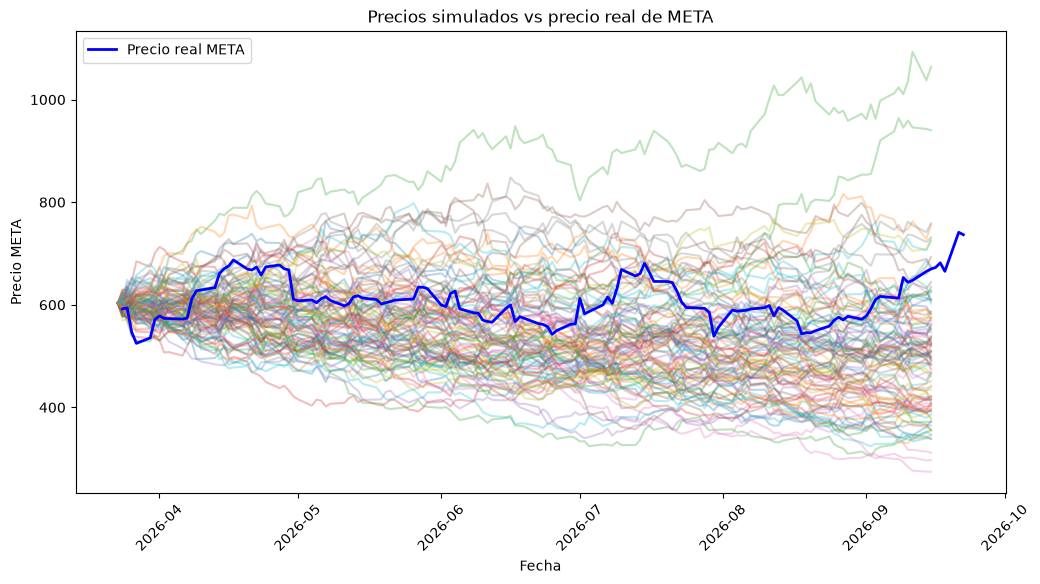

In [10]:
fechas = pd.bdate_range(
    start="2026-03-23",
    periods=n + 1
)

plt.figure(figsize=(12,6))

# 100 precios simulados
for i in range(100):
    plt.plot(fechas, precios[i], alpha=0.3)

# Precio real de META
plt.plot(
    prices.index,
    prices.values,
    label="Precio real META",
    color="blue",
    linewidth=2
)

plt.xlabel("Fecha")
plt.ylabel("Precio META")
plt.title("Precios simulados vs precio real de META")
plt.legend()
plt.xticks(rotation=45)

plt.show()